In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
import contractions
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
import joblib
from sklearn.svm import LinearSVC
from gensim.models import Word2Vec

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Sha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Sha\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Sha\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [4]:
df = pd.read_csv('Amazon_sentiment_analysis.csv')

Explor Data

In [5]:
df.shape[0]

40000

In [6]:
df.columns

Index(['Unnamed: 0', 'marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_body', 'review_date'],
      dtype='object')

In [7]:
df.shape

(40000, 16)

In [8]:
df.head()

,Unnamed: 0,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,0,US,45283875,R131LUTLVH63V2,B003FGWF04,645498686,HH54VP series,Electronics,5.0,0.0,0.0,N,Y,Works GREAT !! Easy to program for home or mob...,Works GREAT !! Easy to program for home or mob...,2015-02-06
1,1,US,23457831,R1NUKNPRX36HIX,B00JAAJ1F6,374159046,Jarv NMotion Sport Wireless Bluetooth 4.0 Ster...,Electronics,5.0,0.0,0.0,N,Y,Best Bang for Your Buck in Wireless Headphones...,Best purchase of my life. These headphones boa...,2015-05-15
2,2,US,6731054,R1VSYY38KIHPIH,B00NM4LKJG,154075815,AUSDOM M04S Over Ear Bluetooth Headphone Advan...,Electronics,5.0,1.0,1.0,N,Y,Awesome!!,Perfect my daughter love them!!!,2014-12-31
3,3,US,46880374,R3RGO8LHIKB1SF,B00ICV26DS,522586369,"Beats by Dr.Dre in Ear Head Phones, Black",Electronics,5.0,0.0,0.0,N,Y,Five Stars,Yes they did.,2014-11-30
4,4,US,34512918,R27W2ZQJOZEH3V,B0046H8ZHS,335809885,SleepPhones Classic Sleep Headphones,Electronics,5.0,0.0,0.0,N,Y,Five Stars,This has made all the difference for me with r...,2015-05-17


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         40000 non-null  int64  
 1   marketplace        40000 non-null  object 
 2   customer_id        40000 non-null  int64  
 3   review_id          40000 non-null  object 
 4   product_id         40000 non-null  object 
 5   product_parent     40000 non-null  int64  
 6   product_title      40000 non-null  object 
 7   product_category   40000 non-null  object 
 8   star_rating        40000 non-null  float64
 9   helpful_votes      40000 non-null  float64
 10  total_votes        40000 non-null  float64
 11  vine               40000 non-null  object 
 12  verified_purchase  40000 non-null  object 
 13  review_headline    39998 non-null  object 
 14  review_body        39989 non-null  object 
 15  review_date        39997 non-null  object 
dtypes: float64(3), int64(3

In [10]:
cols = df.columns
for col in cols :
    print(df[col].isnull().sum())

0
0
0
0
0
0
0
0
0
0
0
0
0
2
11
3


In [11]:
df['star_rating'].value_counts()

star_rating
5.0    16107
1.0     9500
3.0     6116
2.0     4384
4.0     3893
Name: count, dtype: int64

In [12]:
df['star_rating'].unique()

array([5., 4., 1., 2., 3.])

In [13]:
df['vine'].unique()

array(['N', 'Y'], dtype=object)

In [14]:
df['verified_purchase'].unique()

array(['Y', 'N'], dtype=object)

Data Preprocessing

In [15]:
#remove any row that contains at least one missing column

df = df.dropna()

In [16]:
#convert float64 type into int64 type

df['star_rating'] = df['star_rating'].astype(float).astype(int)
df['helpful_votes'] = df['helpful_votes'].astype(float).astype(int)
df['total_votes'] = df['total_votes'].astype(float).astype(int)

In [17]:
#convert review_date into datetime format

df['review_date'] = pd.to_datetime(df['review_date'])

In [18]:
#drop unusefull features

col_to_drop = ['Unnamed: 0' , 'marketplace', 'review_id', 'customer_id', 'product_parent','product_id', 'product_title']
df.drop(col_to_drop, axis=1, inplace=True)

In [19]:
#encode categorical values to numercial values

cols_to_encode = ['vine', 'verified_purchase']
for col in cols_to_encode:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])

In [20]:
#generate compound score according to review_body column

analyzer = SentimentIntensityAnalyzer()
df['compound'] = df['review_body'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

In [21]:
#convert compound score into labels

df['compound_label'] = df['compound'].apply(lambda score: 1 if score > 0 else 0)

Context Preprocessing

In [22]:
for i in range(10) :
    print(i)
    print(df['review_body'][i])
    

0
Works GREAT !! Easy to program for home or mobile.
1
Best purchase of my life. These headphones boast so much acoustic noise canceling that it's almost a distraction at work. They hold a charge for at least 4 hours, all while my iPhone is charging and I have tunes and podcasts without worrying about my iPhone battery life. Charge the headphones during lunch and I have wireless sound all day (10+ hours). Buying my second pair now, as my last pair went through the wash twice (survived the first time, second killed 'em).<br /><br />Love these headphones and recommend them to all my coworkers.
2
Perfect my daughter love them!!!
3
Yes they did.
4
This has made all the difference for me with respect to my spouse's snoring.
5
Bought two of these. Heavy duty and includes cable and magnetic level. Great comparably for the price.
6
The stranded wires are not as heavy gauge as I would have liked. But all in all, it was quite workable for the price and my purposes (power cable for 4 x 1.2V NiMH 

In [23]:
def expand_contractions(text):

    expanded_text = contractions.fix(text)
    return expanded_text


In [24]:
def lowercasing_text(text) :

    lower_text = text.lower()
    return lower_text


In [25]:
def clean_text(text):
    
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'[\W_]+', ' ', text)
    clean_text = re.sub(r'\s+', ' ', text).strip()
    return clean_text

In [26]:
def tokenize_text(text) :

    tokens = word_tokenize(text)
    tokenized_text = [token for token in tokens]
    join_text = ' '.join(tokenized_text)
    return join_text


In [27]:
def remove_stopWords(text):


    STOP_WORDS = [
    # Articles & Determiners
    "a", "an", "the", "this", "that", "these", "those",
    # Conjunctions
    "and", "or", "but", "so", "for", "yet",
    # Prepositions
    "in", "on", "at", "by", "with", "about", "against", "between", "into",
    "through", "during", "before", "after", "above", "below", "to", "from",
    "up", "down", "out", "over", "under",
    # Pronouns
    "i", "me", "my", "mine", "you", "your", "yours", "he", "him", "his",
    "she", "her", "hers", "it", "its", "we", "us", "our", "ours", "they",
    "them", "their", "theirs",
    # Auxiliary Verbs (non-negating)
    "am", "is", "are", "was", "were", "be", "been", "being",
    "do", "does", "did", "have", "has", "had",
    # Modal Verbs (non-negating)
    "can", "could", "shall", "should", "will", "would", "may", "might", "must",
    # Quantifiers & Numericals
    "all", "any", "both", "half", "many", "much", "few", "several", "some",
    # Common Fillers & Discourse Markers
    "just", "also", "too", "even", "then", "there", "here",
    "who", "whom", "which", "what", "when", "where", "why", "how",
    # Temporal Adverbs
    "always", "often", "usually", "sometimes", "rarely", "ever", "still", "already",
    # Optional Intensity Words
    "very", "really", "extremely", "quite"
]
    
    
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in STOP_WORDS]
    return " ".join(filtered_words)

In [2]:
def lemmatize_text(text) :

    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    lemmatized_text = [lemmatizer.lemmatize(token) for token in tokens]
    join_text = ' '.join(lemmatized_text)
    return join_text

In [28]:
#expand contractions

df['review_body'] = df['review_body'].apply(expand_contractions)

In [29]:
#lowercase 

df['review_body'] = df['review_body'].apply(lowercasing_text)

In [30]:
#Remove HTML tags, URLs, puncuations and underscores

df['review_body'] = df['review_body'].apply(clean_text)

In [31]:
#tokenize

df['review_body'] = df['review_body'].apply(tokenize_text)

In [32]:
#remove stopwords

df['review_body'] = df['review_body'].astype(str).apply(remove_stopWords)

In [33]:
#lemmatize 

df['review_body'] = df['review_body'].astype(str).apply(lemmatize_text)

In [34]:
for i in range(10) :
    print(i)
    print(df['review_body'][i])

0
work great easy program home mobile
1
best purchase of life headphone boast acoustic noise canceling almost distraction work hold charge least 4 hour while iphone charging tune podcasts without worrying iphone battery life charge headphone lunch wireless sound day 10 hour buying second pair now a last pair went wash twice survived first time second killed love headphone recommend coworkers
2
perfect daughter love
3
yes
4
made difference respect spouse s snoring
5
bought two of heavy duty includes cable magnetic level great comparably price
6
stranded wire not a heavy gauge a liked workable price purpose power cable 4 x 1 2v nimh battery pack good soldering job followed shrink tubing electrical tape made sturdy
7
great quality dvd sharp picture
8
great now cousin hook speaker dj gig bringing huge cable lol light weight black thick long great sound quality
9
sound great especially size love take little space desk delivers great sound wish turned automatically turn computer not turn off

In [35]:
def map_sentiment(star) :

    if star <= 3 :
        return 0
    else :
        return 1

In [36]:
#convert star_rating into sentiement labels 0 for negative and 1 for positive

df['star_rating_label'] = df['star_rating'].apply(map_sentiment)

Data Visualizaing

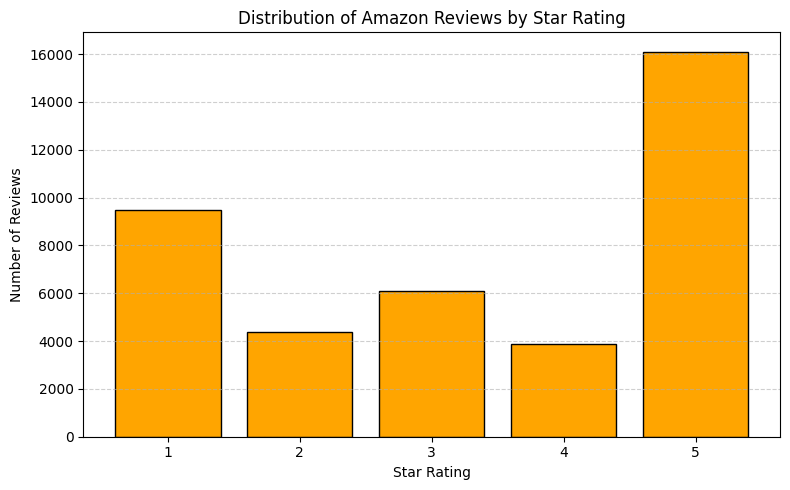

In [37]:
rating_counts = df['star_rating'].value_counts().sort_index()


plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index.astype(str), rating_counts.values, color='orange', edgecolor='black')


plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Amazon Reviews by Star Rating')
plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

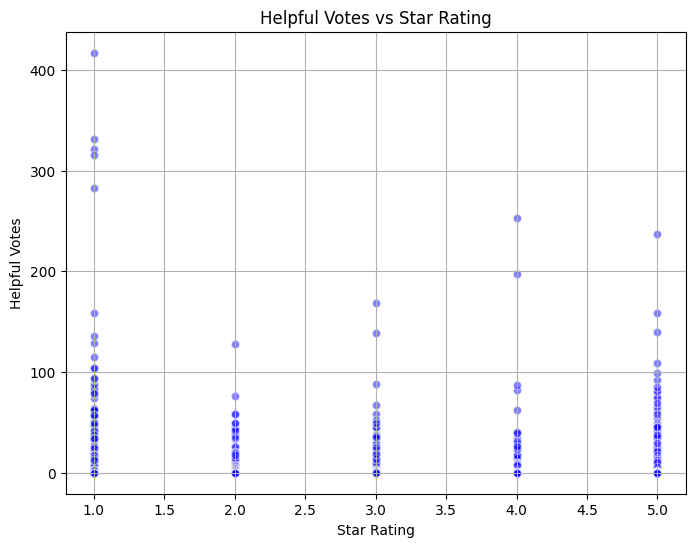

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(df['star_rating'], df['helpful_votes'], alpha=0.5, c='blue', edgecolors='w')


plt.xlabel('Star Rating')
plt.ylabel('Helpful Votes')
plt.title('Helpful Votes vs Star Rating')
plt.grid(True)


plt.show()

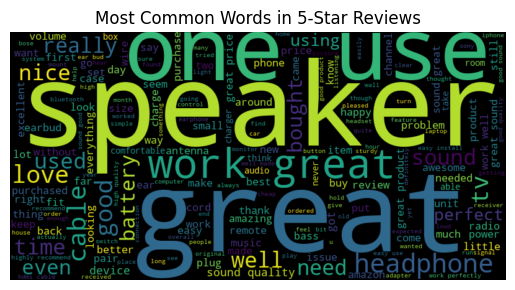

In [39]:
text_5star = " ".join(df[df['star_rating'] == 5]['review_body'])
wordcloud = WordCloud(width=800, height=400).generate(text_5star)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in 5-Star Reviews")
plt.show()

Vectorization

In [41]:
vectorizer = TfidfVectorizer(max_features=5000)
x = vectorizer.fit_transform(df['review_body'])

In [42]:
y = df['star_rating_label']

In [43]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [44]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [45]:
y_pred = model.predict(x_test)

In [ ]:
accuracy_score = accuracy_score(y_test, y_pred)
precision_score = precision_score(y_test, y_pred, average='binary')
recall_score = recall_score(y_test, y_pred, average='binary')
f1_score = f1_score(y_test, y_pred, average='binary')

In [51]:
print(accuracy_score)
print(precision_score)
print(recall_score)
print(f1_score)

0.8675918979744937
<function precision_score at 0x000001D8B49F3B00>
<function recall_score at 0x000001D8B49F3C40>
<function f1_score at 0x000001D8B49F32E0>


Create tf_idf vectorizer with bigram

In [ ]:
vectorizer_with_12grams = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)

In [66]:
x_12grams = vectorizer_with_12grams.fit_transform(df['review_body'])
y_12grams = df['star_rating_label']

Training Logistic Regression

In [67]:
X_train, X_test, y_train, y_test = train_test_split(x_12grams, y_12grams, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000)  
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [69]:
y_pred = model.predict(X_test)

In [70]:
print("🔍 Evaluation Metrics")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

🔍 Evaluation Metrics
Accuracy: 0.8795948987246812
Precision: 0.879820653378506
Recall: 0.8795948987246812
F1 Score: 0.8795836326353681

📊 Confusion Matrix:
 [[3549  434]
 [ 529 3486]]

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88      3983
           1       0.89      0.87      0.88      4015

    accuracy                           0.88      7998
   macro avg       0.88      0.88      0.88      7998
weighted avg       0.88      0.88      0.88      7998



Create tf_idf vectorizer with trigram

In [51]:
vectorizer_with_13grams = TfidfVectorizer(ngram_range=(1, 3), max_features=10000)

In [52]:
x_13grams = vectorizer_with_13grams.fit_transform(df['review_body'])
y_13grams = df['star_rating_label']


X_train, X_test, y_train, y_test = train_test_split(x_13grams, y_13grams, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)  
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("🔍 Evaluation Metrics")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))




🔍 Evaluation Metrics
Accuracy: 0.8793448362090522
Precision: 0.8796726284379219
Recall: 0.8793448362090522
F1 Score: 0.8793268306827511

📊 Confusion Matrix:
 [[3558  425]
 [ 540 3475]]

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88      3983
           1       0.89      0.87      0.88      4015

    accuracy                           0.88      7998
   macro avg       0.88      0.88      0.88      7998
weighted avg       0.88      0.88      0.88      7998



In [53]:
sample = [" not good at all "]
sample_vec = vectorizer_with_13grams.transform(sample)
print(model.predict(sample_vec))

[0]


Training Logistic Regression with compound label

In [38]:
df['compound_label_1'] = df['compound'].apply(lambda score: 1 if score > 0.5 else 0)

In [42]:
vectorizer_with_12grams = joblib.load('tfidf_vectorizer_with_12grams.pkl')

In [ ]:
x_compound = vectorizer_with_12grams.fit_transform(df['review_body'])
y_compound = df['compound_label_1']


X_train, X_test, y_train, y_test = train_test_split(x_compound, y_compound, test_size=0.2, random_state=42)


model_comp = LogisticRegression(max_iter=1000)  
model_comp.fit(X_train, y_train)


y_pred = model_comp.predict(X_test)


print("🔍 Evaluation Metrics")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

🔍 Evaluation Metrics
Accuracy: 0.8818454613653414
Precision: 0.8824316750955696
Recall: 0.8818454613653414
F1 Score: 0.881183292762056

📊 Confusion Matrix:
 [[4199  343]
 [ 602 2854]]

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.92      0.90      4542
           1       0.89      0.83      0.86      3456

    accuracy                           0.88      7998
   macro avg       0.88      0.88      0.88      7998
weighted avg       0.88      0.88      0.88      7998



In [39]:
model_compo = joblib.load('LogisticReg_model_with_tfidf_12grams_with_compound_label.pkl')

vectorizer_with_13grams = joblib.load('tfidf_vectorizer_with_13grams.pkl')

In [41]:
sample = ["not good amazing product"]
sample_vec = vectorizer_with_13grams.transform(sample)
print(model_compo.predict(sample_vec))

[0]


Training Logistic regression with Cross Validation

In [46]:
X = df['review_body']
y = df['star_rating_label']

In [47]:
pipeline = make_pipeline(
    TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1, 2)),
    LogisticRegression(max_iter=1000)
)


In [48]:
scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')


In [49]:
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.84146037 0.84021005 0.84581718 0.84944354 0.83943979]
Mean accuracy: 0.8432741860593321


Training Naive Bayes Model

In [ ]:
X = df['review_body']
y = df['star_rating_label']         

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

MultinomialNB()

In [ ]:
y_pred = nb_model.predict(X_test_vec)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.86      0.85      3983
           1       0.86      0.83      0.84      4015

    accuracy                           0.85      7998
   macro avg       0.85      0.85      0.85      7998
weighted avg       0.85      0.85      0.85      7998

[[3436  547]
 [ 692 3323]]


In [ ]:
sample = [" not good at all "]
sample_vec = vectorizer.transform(sample)
print(nb_model.predict(sample_vec))


[1]


Tuning Naive Beysa Model

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

In [ ]:
param_grid = {
    'nb__alpha': [0.001, 0.01, 0.1, 0.5, 1, 5, 10],
    'tfidf__ngram_range': [(1,1), (1,2), (1,3)],
    'tfidf__max_df': [0.75, 0.85, 1.0], 
    'tfidf__min_df': [1, 2, 5]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(df['review_body'], df['star_rating_label']) 


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('nb', MultinomialNB())]),
             n_jobs=-1,
             param_grid={'nb__alpha': [0.001, 0.01, 0.1, 0.5, 1, 5, 10],
                         'tfidf__max_df': [0.75, 0.85, 1.0],
                         'tfidf__min_df': [1, 2, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)]},
             scoring='accuracy')

In [56]:
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)


Best Parameters: {'nb__alpha': 0.5, 'tfidf__max_df': 0.75, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 3)}
Best Accuracy: 0.8715582640814636


In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
param_grid = {'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]}

grid_search = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_vec, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)


Best alpha: {'alpha': 2.0}
Best score: 0.8421645071103636


In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_vec)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.86      0.85      3983
           1       0.86      0.83      0.84      4015

    accuracy                           0.84      7998
   macro avg       0.84      0.84      0.84      7998
weighted avg       0.85      0.84      0.84      7998



Training Logistic Regression with word2vec vectorizer

In [ ]:

df['tokens'] = df['review_body'].apply(lambda x: x.split())


In [64]:
sentences = df['tokens'].tolist()

In [ ]:
w2v_model = Word2Vec(
    sentences,
    vector_size=100,     
    window=5,            
    min_count=2,         
    workers=4,           
    sg=1                 
)


In [67]:
def review_to_vec(tokens, model):
    vecs = [model.wv[word] for word in tokens if word in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

In [68]:
df['vector'] = df['tokens'].apply(lambda x: review_to_vec(x, w2v_model))

In [69]:
X = np.vstack(df['vector'].values)

In [70]:
y = df['star_rating_label']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

In [73]:
y_pred = clf.predict(X_test)

In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83      3983
           1       0.85      0.80      0.82      4015

    accuracy                           0.83      7998
   macro avg       0.83      0.83      0.83      7998
weighted avg       0.83      0.83      0.83      7998



Training Logistic Regression with review_headline column

In [ ]:
#apply preprocessing on review_hheadline

df['review_headline'] = df['review_headline'].apply(expand_contractions)
df['review_headline'] = df['review_headline'].apply(lowercasing_text)
df['review_headline'] = df['review_headline'].apply(clean_text)
df['review_headline'] = df['review_headline'].apply(tokenize_text)
df['review_headline'] = df['review_headline'].apply(remove_stopWords)
df['review_headline'] = df['review_headline'].apply(lemmatize_text)

In [44]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)

In [46]:
x = vectorizer.fit_transform(df['review_headline'])
y = df['star_rating_label']


X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


model2 = LogisticRegression(max_iter=1000)  
model2.fit(X_train, y_train)


y_pred = model2.predict(X_test)

In [47]:
print("🔍 Evaluation Metrics")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

🔍 Evaluation Metrics
Accuracy: 0.8879719929982496
Precision: 0.8881786603930315
Recall: 0.8879719929982496
F1 Score: 0.8879628506627882

📊 Confusion Matrix:
 [[3580  403]
 [ 493 3522]]

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89      3983
           1       0.90      0.88      0.89      4015

    accuracy                           0.89      7998
   macro avg       0.89      0.89      0.89      7998
weighted avg       0.89      0.89      0.89      7998



Trainning SVM Model

In [39]:
vectorizer =  joblib.load('tfidf_vectorizer.pkl')

In [40]:
X = vectorizer.fit_transform(df['review_body'])

y = df['star_rating_label']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [44]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)


LinearSVC()

In [45]:
y_pred = svm_model.predict(X_test)

In [46]:
print("Accuracy : " , accuracy_score(y_test , y_pred))

Accuracy :  0.8567141785446362


In [47]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.86      3983
           1       0.86      0.85      0.86      4015

    accuracy                           0.86      7998
   macro avg       0.86      0.86      0.86      7998
weighted avg       0.86      0.86      0.86      7998



In [36]:
vectorizer_with_12grams = joblib.load('tfidf_vectorizer_with_12grams.pkl')

In [49]:
X = vectorizer_with_12grams.fit_transform(df['review_body'])

y = df['star_rating_label']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [51]:
svm_model1 = LinearSVC()
svm_model1.fit(X_train , y_train)

LinearSVC()

In [53]:
y_pred = svm_model1.predict(X_test)

In [54]:
print("Accuracy :"  ,accuracy_score(y_test , y_pred))

Accuracy : 0.8730932733183295


In [55]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.88      0.87      3983
           1       0.88      0.87      0.87      4015

    accuracy                           0.87      7998
   macro avg       0.87      0.87      0.87      7998
weighted avg       0.87      0.87      0.87      7998



In [56]:
vectorizer_with_13grams = joblib.load('tfidf_vectorizer_with_13grams.pkl')

In [ ]:
X = vectorizer_with_13grams(df['review_body'])

y = df['star_rating_label']

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [58]:
svm_model2 = LinearSVC()
svm_model2.fit(X_train , y_train)

LinearSVC()

In [60]:
y_pred = svm_model2.predict(X_test)

In [61]:
print("accuracy :" , accuracy_score(y_test , y_pred))

accuracy : 0.8730932733183295


Tuning SVM Model

In [64]:
param_grid = {'C': [0.01, 0.1, 1, 10]}
grid_search = GridSearchCV(LinearSVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=LinearSVC(), param_grid={'C': [0.01, 0.1, 1, 10]})

In [65]:
best_params = grid_search.best_params_

In [66]:
optimized_svm = LinearSVC(**best_params)
optimized_svm.fit(X_train, y_train)


LinearSVC(C=0.1)

In [ ]:
y_pred_optimized = optimized_svm.predict(X_test)

In [68]:
print("Optimized Accuracy:", accuracy_score(y_test, y_pred_optimized))
print("Optimized Classification Report:\n", classification_report(y_test, y_pred_optimized))

Optimized Accuracy: 0.8810952738184546
Optimized Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88      3983
           1       0.89      0.87      0.88      4015

    accuracy                           0.88      7998
   macro avg       0.88      0.88      0.88      7998
weighted avg       0.88      0.88      0.88      7998



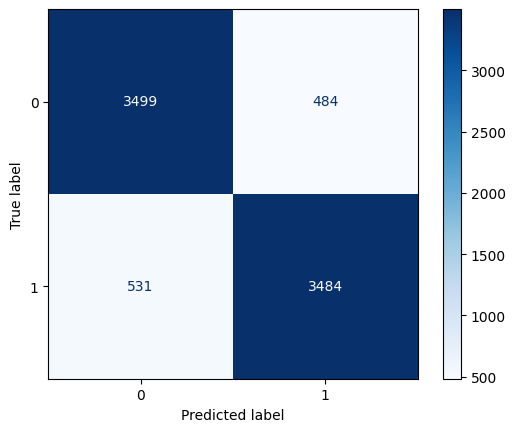

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap='Blues')


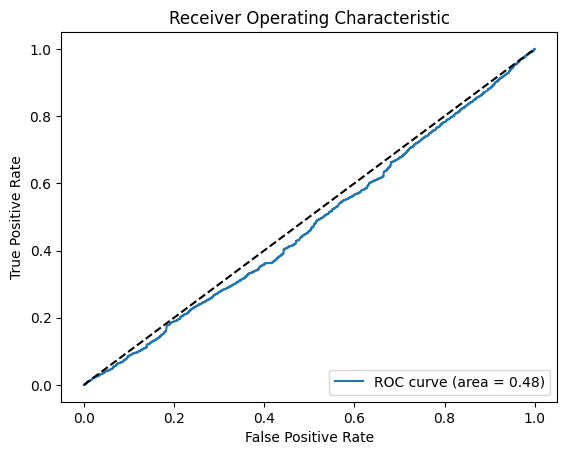

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_scores = svm_model.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


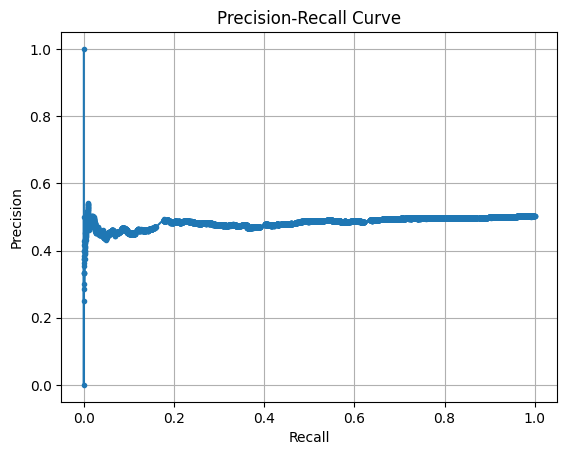

In [73]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.figure()
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()  
coefficients = svm_model.coef_.flatten()
top_positive = np.argsort(coefficients)[-10:]
top_negative = np.argsort(coefficients)[:10]

print("Top Positive Words:", feature_names[top_positive])
print("Top Negative Words:", feature_names[top_negative])


Top Positive Words: ['highly' 'worry' 'complain' 'plenty' 'bonus' 'perfectly' 'pleased'
 'awesome' 'great' 'amazing']
Top Negative Words: ['not' 'disappointing' 'return' 'refund' 'returning' 'stopped' 'mediocre'
 'horrible' 'terrible' 'returned']


Trying to use Bert Model

In [36]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('../assets/bert-base-uncased/')
bert_model = BertModel.from_pretrained('../assets/bert-base-uncased/')


C:\Users\Sha\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [39]:
import torch

def tokenize_reviews(reviews, max_length=32):
    return tokenizer(
        reviews,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )


def get_embeddings_in_batches(reviews, batch_size=32):
    all_embeddings = []
    for i in range(0, len(reviews), batch_size):
        batch = reviews[i:i+batch_size]
        tokenized = tokenizer(batch, padding=True, truncation=True, return_tensors='pt')
        with torch.no_grad():
            outputs = bert_model(**tokenized)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu())
    return torch.cat(all_embeddings, dim=0)



def convert_to_numpy(tensor):
    return tensor.cpu().numpy()




In [46]:
reviews = df['review_body'].astype(str).to_list()

In [ ]:
embeddings = get_embeddings_in_batches(reviews) 

: 